|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Understand and design CNNs<h1>|
|<h2>Lecture:</h2>|<h1><b>Do autoencoders clean Gaussians?<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# model summary info
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Create Gaussian blurs with varying widths and occluding bars

In [2]:
nGauss  = 1000
imgSize = 91

x = np.linspace(-4,4,imgSize)
X,Y = np.meshgrid(x,x)

# vary the weights smoothly
widths = np.linspace(2,20,nGauss)

# initialize tensor containing images
images = torch.zeros(nGauss,1,imgSize,imgSize)

for i in range(nGauss):

  # create the gaussian with random centers
  ro = 1.5*np.random.randn(2) # ro = random offset
  G  = np.exp( -( (X-ro[0])**2 + (Y-ro[1])**2) / widths[i] )

  # and add noise
  G  = G + np.random.randn(imgSize,imgSize)/5

  # add a random bar randomly
  i1 = np.random.choice(np.arange(2,28))
  i2 = np.random.choice(np.arange(2,6))
  if np.random.randn()>0:
    G[i1:i1+i2,] = 1
  else:
    G[:,i1:i1+i2] = 1

  # add to the tensor
  images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize)

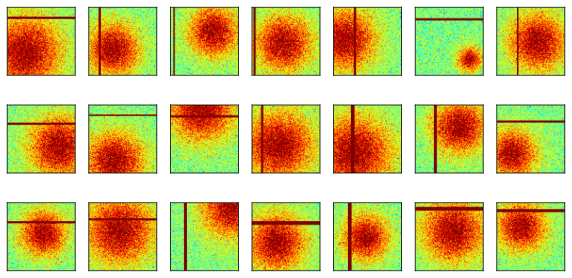

In [3]:
# visualize some images
fig,axs = plt.subplots(3,7,figsize=(10,5))

for i,ax in enumerate(axs.flatten()):
  whichpic = np.random.randint(nGauss)
  G = np.squeeze( images[whichpic,:,:] )
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet')
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Create the DL model

In [13]:
# create a class for the model
def makeTheNet(loss_fn_name:str='MSELoss'):

  class gausnet(nn.Module):
    def __init__(self):
      super().__init__()

      # encoding layer
      self.enc = nn.Sequential(
          nn.Conv2d(1,6,3,padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2,2),
          nn.Conv2d(6,4,3,padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2,2)
          )

      # decoding layer
      self.dec = nn.Sequential(
          nn.ConvTranspose2d(4,6,3,2),
          nn.ReLU(),
          nn.ConvTranspose2d(6,1,3,2),
          )

    def forward(self,x):
      return self.dec( self.enc(x) )
    
  class myL1Loss(nn.Module):
    def __init__(self):
      super().__init__()

    def forward(self,yHat,y):
      return (yHat - y).abs_().mean()
    
  class myL2AveLoss(nn.Module):
    def __init__(self):
      super().__init__()

    def forward(self,yHat,y,gamma:float=.1):
      L2_1 = nn.MSELoss()(yHat,y)
      L2_2 = yHat.sum().abs_() / (yHat.shape[0] * yHat.shape[2] * yHat.shape[3])
      return gamma * L2_1 + (1.0 - gamma) * L2_2
    
  class myCorrLoss(nn.Module):
    def __init__(self):
      super().__init__()

    def forward(self,yHat,y):
      N = ((yHat - yHat.mean()) * (y - y.mean())).sum()
      D = ((torch.numel(yHat) - 1) * yHat.std() * y.std()) 
      return -N / D
    
  class myVarLoss(nn.Module):
    def __init__(self):
      super().__init__()

    def forward(self,yHat,y):
      L = (yHat.var() - y.var()).abs()
      return L

  # create the model instance
  net = gausnet()

  # loss function
  lossfun = myCorrLoss()
  loss_fn_dict = {
      'myL1Loss': myL1Loss(),
      'myL2AveLoss': myL2AveLoss(),
      'myCorrLoss': myCorrLoss(),
      'myVarLoss': myVarLoss(),
      'MSELoss': nn.MSELoss(),
  }
  lossfun = loss_fn_dict[loss_fn_name]

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

tensor(0.0513, grad_fn=<StdBackward0>)
 
torch.Size([10, 1, 91, 91])


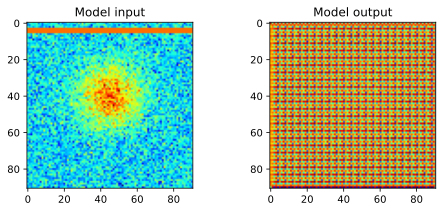

In [14]:
# test the model with one batch
net,lossfun,optimizer = makeTheNet()

yHat = net(images[:10,:,:,:])

print(yHat.std())

# check size of output
print(' ')
print(yHat.shape)

# let's see how they look
fig,ax = plt.subplots(1,2,figsize=(8,3))
ax[0].imshow(torch.squeeze(images[0,0,:,:]).detach(),cmap='jet')
ax[0].set_title('Model input')
ax[1].imshow(torch.squeeze(yHat[0,0,:,:]).detach(),cmap='jet')
ax[1].set_title('Model output')

plt.show()

In [15]:
# count the total number of parameters in the model
summary(net,(1,imgSize,imgSize), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         MaxPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         MaxPool2d-6            [-1, 4, 22, 22]               0
   ConvTranspose2d-7            [-1, 6, 45, 45]             222
              ReLU-8            [-1, 6, 45, 45]               0
   ConvTranspose2d-9            [-1, 1, 91, 91]              55
Total params: 557
Trainable params: 557
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.24
Params size (MB): 0.00
Estimated Total Size (MB): 1.27
---------------------------------------------------

# Create a function that trains the model

In [16]:
# a function that trains the model

def function2trainTheModel():

  # number of epochs
  numepochs = 2*500

  # create a new model
  net,lossfun,optimizer = makeTheNet('myCorrLoss')

  # initialize losses
  losses = torch.zeros(numepochs)

  # loop over epochs
  for epochi in range(numepochs):

    # pick a set of images at random
    pics2use = np.random.choice(nGauss,size=32,replace=False)
    X = images[pics2use,:,:,:]

    # forward pass and loss
    yHat = net(X)
    loss = lossfun(yHat,X)
    losses[epochi] = loss.item()

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  # end epochs

  # function output
  return losses,net

# Run the model and show the results!

In [17]:
# test the model on a bit of data
losses,net = function2trainTheModel()

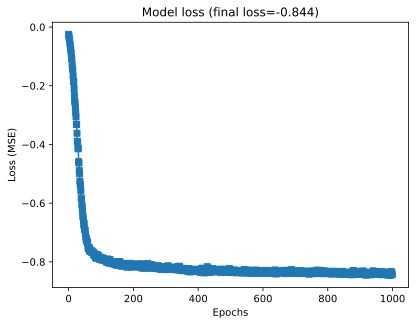

In [18]:
plt.plot(losses,'s-',label='Train')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Model loss (final loss=%.3f)'%losses[-1])

plt.show()

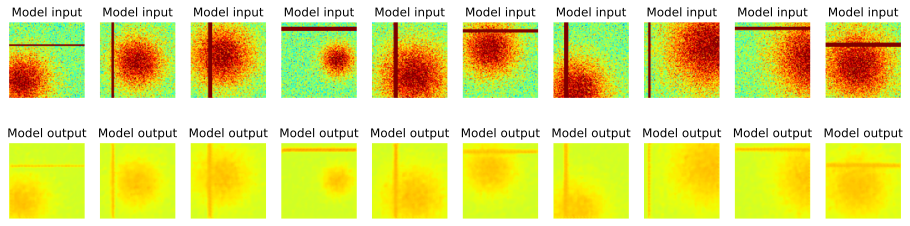

In [19]:
# visualize some images

pics2use = np.random.choice(nGauss,size=32,replace=False)
X = images[pics2use,:,:,:]
yHat = net(X)

fig,axs = plt.subplots(2,10,figsize=(16,4))

for i in range(10):

  G = torch.squeeze( X[i,0,:,:] ).detach()
  O = torch.squeeze( yHat[i,0,:,:] ).detach()

  axs[0,i].imshow(G,vmin=-1,vmax=1,cmap='jet')
  axs[0,i].axis('off')
  axs[0,i].set_title('Model input')

  axs[1,i].imshow(O,vmin=-1,vmax=1,cmap='jet')
  axs[1,i].axis('off')
  axs[1,i].set_title('Model output')

plt.show()

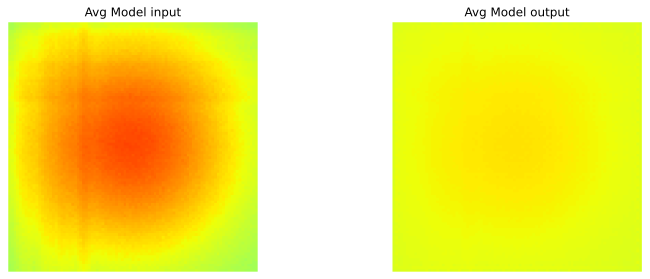

In [20]:
X = images[:,:,:,:]
yHat = net(X)

X_avg = torch.mean(X,dim=0,keepdim=True)
yHat_avg = torch.mean(yHat,dim=0,keepdim=True)

G_avg = torch.squeeze( X_avg[0,0,:,:] ).detach()
O_avg = torch.squeeze( yHat_avg[0,0,:,:] ).detach()

fig,axs = plt.subplots(1,2,figsize=(12,4))

axs[0].imshow(G_avg,vmin=-1,vmax=1,cmap='jet')
axs[0].set_title('Avg Model input')

axs[1].imshow(O_avg,vmin=-1,vmax=1,cmap='jet')
axs[1].set_title('Avg Model output')

for ax in axs:
  ax.axis('off')
  
fig.tight_layout()
plt.show()

# Additional explorations

In [21]:
# 1) The code in this notebook requires "manually" switching between loss functions by (un)commenting. Modify the
#    code so that you can list the name of the loss function as an input to makeTheNet().
#
# 2) Here's an interesting loss function: minimize the variance of the model's output. Don't worry about comparing
#    to the input image; just set the loss function to be the variance of the output. What do the results look like,
#    and why does this happen?
#
# 3) What if L2 minimization (MSE) is more important than average minimization? Modify the L2LossAve class so that the
#    average has a weaker influence compared to the L2 loss.
#
#
# Reminder: This codeChallenge was designed to be a fun exercise to introduce you to the mechanics of creating and using
#           custom-built loss functions. The PyTorch built-in MSELoss is actually the best one to use for autoencoders
#           in most cases.
#